## Train a simple convnet on the Fashion MNIST dataset

In this, we will see how to deal with image data and train a convnet for image classification task.

### Load the  `fashion_mnist`  dataset

** Use keras.datasets to load the dataset **

In [0]:
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt

In [2]:
from keras.utils.np_utils import to_categorical

Using TensorFlow backend.


In [0]:
from keras.layers import Dropout

In [0]:
from keras.datasets import fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

### Find no.of samples are there in training and test datasets

In [5]:
x_train.shape, y_train.shape

((60000, 28, 28), (60000,))

In [6]:
y_train

array([9, 0, 0, ..., 3, 0, 5], dtype=uint8)

### Find dimensions of an image in the dataset

In [7]:
#Dimension of the image is 28x28
x_train.shape

(60000, 28, 28)

### Convert train and test labels to one hot vectors

** check `keras.utils.to_categorical()` **

In [0]:
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

In [9]:
y_train[0],y_train_cat[0]

(9, array([0., 0., 0., 0., 0., 0., 0., 0., 0., 1.], dtype=float32))

### Normalize both the train and test image data from 0-255 to 0-1

In [0]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

### Reshape the data from 28x28 to 28x28x1 to match input dimensions in Conv2D layer in keras

In [0]:
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

In [12]:
x_train.shape, x_test.shape

((60000, 28, 28, 1), (10000, 28, 28, 1))

### Import the necessary layers from keras to build the model

In [0]:
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPool2D, Flatten
import keras.backend as K

### Build a model 

** with 2 Conv layers having `32 3*3 filters` in both convolutions with `relu activations` and `flatten` before passing the feature map into 2 fully connected layers (or Dense Layers) having 128 and 10 neurons with `relu` and `softmax` activations respectively. Now, using `categorical_crossentropy` loss with `adam` optimizer train the model with early stopping `patience=5` and no.of `epochs=10`. **

In [14]:
#Instantiate a model
model = Sequential()

# 2D Conv layer 32 filters/kernals of size 3x3 and relu activatin.
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))

#Flatten before passing on to Dense layers
model.add(Flatten())

# First Dense layer with 128 neurons and relu activation
model.add(Dense(128, activation='relu'))

# Second Dense layer with 10 neurons(since there are 10 classes) and softmax activation(since it is output layer)
model.add(Dense(10, activation='softmax'))

# Compiling the model optimiser & cross entropy as it is a classification problem
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

Instructions for updating:
Colocations handled automatically by placer.


In [15]:
model.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_1 (Conv2D)            (None, 26, 26, 32)        320       
_________________________________________________________________
flatten_1 (Flatten)          (None, 21632)             0         
_________________________________________________________________
dense_1 (Dense)              (None, 128)               2769024   
_________________________________________________________________
dense_2 (Dense)              (None, 10)                1290      
Total params: 2,770,634
Trainable params: 2,770,634
Non-trainable params: 0
_________________________________________________________________


In [16]:
#Fitting the model 
model.fit(x_train, y_train_cat, batch_size=128,
          epochs=10, verbose=1, validation_split=0.3)

Instructions for updating:
Use tf.cast instead.
Train on 42000 samples, validate on 18000 samples
Epoch 1/10
42000/42000 [==============================] - 6s 132us/step - loss: 0.4646 - acc: 0.8363 - val_loss: 0.3445 - val_acc: 0.8791
Epoch 2/10
42000/42000 [==============================] - 4s 91us/step - loss: 0.3008 - acc: 0.8919 - val_loss: 0.3062 - val_acc: 0.8905
Epoch 3/10
42000/42000 [==============================] - 4s 91us/step - loss: 0.2481 - acc: 0.9097 - val_loss: 0.2923 - val_acc: 0.8958
Epoch 4/10
42000/42000 [==============================] - 4s 92us/step - loss: 0.2116 - acc: 0.9224 - val_loss: 0.2898 - val_acc: 0.8980
Epoch 5/10
42000/42000 [==============================] - 4s 92us/step - loss: 0.1830 - acc: 0.9330 - val_loss: 0.2804 - val_acc: 0.9038
Epoch 6/10
42000/42000 [==============================] - 4s 92us/step - loss: 0.1548 - acc: 0.9435 - val_loss: 0.2934 - val_acc: 0.9012
Epoch 7/10
42000/42000 [==============================] - 4s 91us/step - loss: 

In [17]:
model.evaluate(x_test, y_test_cat)

10000/10000 [==============================] - 1s 64us/step


[0.33525701038241384, 0.9005]

### Now, to the above model add `max` pooling layer of `filter size 2x2` and `dropout` layer with `p=0.25` after the 2 conv layers and run the model

In [18]:
#Instantiate a model
model = Sequential()

# 2D Conv layer 32 filters/kernals of size 3x3 and relu activatin.
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))

# max pooling layer of filter size 2x2 
model.add(MaxPool2D(pool_size=(2, 2)))

#Adding a dropout layer to prevent over fitting
model.add(Dropout(0.2))

#Flatten before passing on to Dense layers
model.add(Flatten())


# First Dense layer with 128 neurons and relu activation
model.add(Dense(128, activation='relu'))

# Second Dense layer with 10 neurons(since there are 10 classes) and softmax activation(since it is output layer)
model.add(Dense(10, activation='softmax'))

# Compiling the model optimiser & cross entropy as it is a classification problem
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

Instructions for updating:
Please use `rate` instead of `keep_prob`. Rate should be set to `rate = 1 - keep_prob`.


In [19]:
model.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_2 (Conv2D)            (None, 26, 26, 32)        320       
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 13, 13, 32)        0         
_________________________________________________________________
dropout_1 (Dropout)          (None, 13, 13, 32)        0         
_________________________________________________________________
flatten_2 (Flatten)          (None, 5408)              0         
_________________________________________________________________
dense_3 (Dense)              (None, 128)               692352    
_________________________________________________________________
dense_4 (Dense)              (None, 10)                1290      
Total params: 693,962
Trainable params: 693,962
Non-trainable params: 0
_________________________________________________________________


In [20]:
#Fitting the model 
model.fit(x_train, y_train_cat, batch_size=128,
          epochs=10, verbose=1, validation_split=0.3)

Train on 42000 samples, validate on 18000 samples
Epoch 1/10
42000/42000 [==============================] - 3s 81us/step - loss: 0.4865 - acc: 0.8273 - val_loss: 0.3508 - val_acc: 0.8766
Epoch 2/10
42000/42000 [==============================] - 3s 71us/step - loss: 0.3290 - acc: 0.8833 - val_loss: 0.3134 - val_acc: 0.8876
Epoch 3/10
42000/42000 [==============================] - 3s 70us/step - loss: 0.2916 - acc: 0.8950 - val_loss: 0.2960 - val_acc: 0.8954
Epoch 4/10
42000/42000 [==============================] - 3s 71us/step - loss: 0.2630 - acc: 0.9038 - val_loss: 0.2747 - val_acc: 0.9023
Epoch 5/10
42000/42000 [==============================] - 3s 70us/step - loss: 0.2396 - acc: 0.9130 - val_loss: 0.2610 - val_acc: 0.9085
Epoch 6/10
42000/42000 [==============================] - 3s 71us/step - loss: 0.2246 - acc: 0.9185 - val_loss: 0.2708 - val_acc: 0.9031
Epoch 7/10
42000/42000 [==============================] - 3s 71us/step - loss: 0.2089 - acc: 0.9221 - val_loss: 0.2588 - val_acc

In [21]:
model.evaluate(x_test, y_test_cat)

10000/10000 [==============================] - 1s 63us/step


[0.26813580543398857, 0.9076]

### Now, to the above model, lets add Data Augmentation 

### Import the ImageDataGenrator from keras and fit the training images

In [0]:
from keras.preprocessing.image import ImageDataGenerator

# This will do preprocessing and realtime data augmentation:
datagen = ImageDataGenerator(
    featurewise_center=False,  # set input mean to 0 over the dataset
    samplewise_center=False,  # set each sample mean to 0
    featurewise_std_normalization=False,  # divide inputs by std of the dataset
    samplewise_std_normalization=False,  # divide each input by its std
    zca_whitening=False,  # apply ZCA whitening
    rotation_range=50,  # randomly rotate images in the range (degrees, 0 to 180)
    width_shift_range=0.1,  # randomly shift images horizontally (fraction of total width)
    height_shift_range=0.1,  # randomly shift images vertically (fraction of total height)
    horizontal_flip=False,  # randomly flip images
    vertical_flip=False)  # randomly flip images

# Prepare the generator
datagen.fit(x_train)

#### Showing 5 versions of the first image in training dataset using image datagenerator.flow()

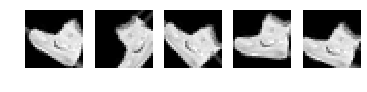

In [23]:
from matplotlib import pyplot as plt
gen = datagen.flow(x_train[0:1], batch_size=1)
for i in range(1, 6):
    plt.subplot(1,5,i)
    plt.axis("off")
    plt.imshow(gen.next().squeeze(), cmap='gray')
    plt.plot()
plt.show()

In [24]:
datagen.flow(x_train, y_train, batch_size=32)

### Run the above model using fit_generator()

In [25]:
# fits the model on batches with real-time data augmentation:
model.fit_generator(datagen.flow(x_train, y_train_cat, batch_size=32),
                    steps_per_epoch=len(x_train) / 32, epochs=10)

Epoch 1/10
1875/1875 [==============================] - 25s 13ms/step - loss: 0.7104 - acc: 0.7355
Epoch 2/10
1875/1875 [==============================] - 26s 14ms/step - loss: 0.5684 - acc: 0.7891
Epoch 3/10
1875/1875 [==============================] - 25s 13ms/step - loss: 0.5242 - acc: 0.8049
Epoch 4/10
1875/1875 [==============================] - 25s 13ms/step - loss: 0.4974 - acc: 0.8153
Epoch 5/10
1875/1875 [==============================] - 25s 13ms/step - loss: 0.4796 - acc: 0.8207
Epoch 6/10
1875/1875 [==============================] - 25s 13ms/step - loss: 0.4703 - acc: 0.8243
Epoch 7/10
1875/1875 [==============================] - 25s 13ms/step - loss: 0.4577 - acc: 0.8300
Epoch 8/10
1875/1875 [==============================] - 25s 13ms/step - loss: 0.4471 - acc: 0.8333
Epoch 9/10
1875/1875 [==============================] - 25s 13ms/step - loss: 0.4404 - acc: 0.8373
Epoch 10/10
1875/1875 [==============================] - 25s 13ms/step - loss: 0.4311 - acc: 0.8396


###  Report the final train and validation accuracy

In [26]:
model.evaluate(x_test, y_test_cat)

10000/10000 [==============================] - 1s 65us/step


[0.4003307806491852, 0.8637]

## **DATA AUGMENTATION ON CIFAR10 DATASET**

One of the best ways to improve the performance of a Deep Learning model is to add more data to the training set. Aside from gathering more instances from the wild that are representative of the distinction task, we want to develop a set of methods that enhance the data we already have. There are many ways to augment existing datasets and produce more robust models. In the image domain, these are done to utilize the full power of the convolutional neural network, which is able to capture translational invariance. This translational invariance is what makes image recognition such a difficult task in the first place. You want the dataset to be representative of the many different positions, angles, lightings, and miscellaneous distortions that are of interest to the vision task.

### **Import neessary libraries for data augmentation**

In [0]:
from keras.datasets import cifar10
from keras.preprocessing.image import ImageDataGenerator

### **Load CIFAR10 dataset**

In [28]:
# The data, split between train and test sets:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
print('x_train shape:', x_train.shape)
print(x_train.shape[0], 'train samples')
print(x_test.shape[0], 'test samples')

x_train shape: (50000, 32, 32, 3)
50000 train samples
10000 test samples


In [0]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

### **Create a data_gen funtion to genererator with image rotation,shifting image horizontally and vertically with random flip horizontally.**

In [0]:
# This will do preprocessing and realtime data augmentation:
datagen2 = ImageDataGenerator(
    featurewise_center=False,  # set input mean to 0 over the dataset
    samplewise_center=False,  # set each sample mean to 0
    featurewise_std_normalization=False,  # divide inputs by std of the dataset
    samplewise_std_normalization=False,  # divide each input by its std
    zca_whitening=False,  # apply ZCA whitening
    rotation_range=50,  # randomly rotate images in the range (degrees, 0 to 180)
    width_shift_range=0.1,  # randomly shift images horizontally (fraction of total width)
    height_shift_range=0.1,  # randomly shift images vertically (fraction of total height)
    horizontal_flip=True,  # randomly flip images
  vertical_flip=True)  # randomly flip images

### **Prepare/fit the generator.**

In [0]:
# Prepare the generator
datagen2.fit(x_train)

### **Generate 5 images for 1 of the image of CIFAR10 train dataset.**

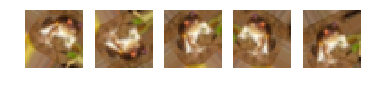

In [32]:
from matplotlib import pyplot as plt
gen = datagen2.flow(x_train[0:1], batch_size=1)
for i in range(1, 6):
    plt.subplot(1,5,i)
    plt.axis("off")
    plt.imshow(gen.next().squeeze(), cmap='gray')
    plt.plot()
plt.show()